# Arabic GPT — Pre-training + Fine-tuning Pipeline
**Cells in order:** Setup → Data → Model → Train → Save/Load → Fine-tune → Chat UI

In [42]:
# ── Cell 1: Imports & Setup ───────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import pandas as pd
import re

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Tokenizer ─────────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained('aubmindlab/aragpt2-base')
tokenizer.pad_token = tokenizer.eos_token

VOCAB_SIZE = tokenizer.vocab_size   # 64,000
EOS_ID     = tokenizer.eos_token_id
print(f'Tokenizer: aubmindlab/aragpt2-base | Vocab: {VOCAB_SIZE:,} | EOS id: {EOS_ID}')

# Sanity check
test  = 'العلم نور والجهل ظلام'
ids   = tokenizer.encode(test)
print(f'Encode→Decode check: {tokenizer.decode(ids)}')

# ── Config ────────────────────────────────────────────────────────────────────
class Config:
    vocab_size     = VOCAB_SIZE
    context_length = 128
    emb_dim        = 256
    n_heads        = 8      # emb_dim must be divisible by n_heads (256/8=32 ✓)
    n_layers       = 6
    drop_rate      = 0.4
    batch_size     = 16
    lr             = 4e-4
    epochs         = 20
cfg = Config()
print(f'Config ready — context={cfg.context_length}, emb={cfg.emb_dim}, layers={cfg.n_layers}')

Device: cuda
Tokenizer: aubmindlab/aragpt2-base | Vocab: 64,000 | EOS id: 0
Encode→Decode check: العلم نور والجهل ظلام
Config ready — context=128, emb=256, layers=6


In [43]:
# ── Cell 2: Data — Pre-training Dataset ──────────────────────────────────────
def clean_arabic(text):
    """Strip non-Arabic characters and normalize whitespace."""
    text = re.sub(r'[^\w\s\u0600-\u06FF]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Load & clean
df = pd.read_parquet(
    'hf://datasets/AbderrahmanSkiredj1/MLM_classical_arabic_openiti/data/train-00000-of-00001-f202266784bed2d5.parquet'
)
df['cleaned'] = df['text'].apply(clean_arabic)

with open('arabic_pretrain.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(df['cleaned'].tolist()[:15000]))

print(f'Saved {len(df["cleaned"].tolist()[:15000])} rows to arabic_pretrain.txt')

# ── Sliding-window Dataset ────────────────────────────────────────────────────
class ArabicTextDataset(Dataset):
    """Creates (input, target) pairs via a sliding window over the token stream."""
    def __init__(self, file_path, tokenizer, max_length, stride):
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read()

        token_ids = tokenizer.encode(text)
        self.input_ids  = []
        self.target_ids = []

        for i in range(0, len(token_ids) - max_length, stride):
            self.input_ids.append(torch.tensor(token_ids[i : i + max_length]))
            self.target_ids.append(torch.tensor(token_ids[i + 1 : i + max_length + 1]))

    def __len__(self):              return len(self.input_ids)
    def __getitem__(self, idx):     return self.input_ids[idx], self.target_ids[idx]

# 80/20 split
full_ds    = ArabicTextDataset('arabic_pretrain.txt', tokenizer, cfg.context_length, stride=128)
train_size = int(0.8 * len(full_ds))
val_size   = len(full_ds) - train_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Saved 15000 rows to arabic_pretrain.txt
Train batches: 333 | Val batches: 84


In [44]:
# ── Cell 3: Model Architecture ────────────────────────────────────────────────

class CausalSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        assert cfg.emb_dim % cfg.n_heads == 0, 'emb_dim must be divisible by n_heads'
        self.c_attn  = nn.Linear(cfg.emb_dim, 3 * cfg.emb_dim)
        self.c_proj  = nn.Linear(cfg.emb_dim, cfg.emb_dim)
        self.n_heads = cfg.n_heads
        self.emb_dim = cfg.emb_dim
        self.drop    = nn.Dropout(cfg.drop_rate)
        # NOTE: causal masking is handled by scaled_dot_product_attention(is_causal=True)
        #       so no manual mask buffer is needed here.

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.emb_dim, dim=2)
        # Reshape to (B, n_heads, T, head_dim)
        q = q.view(B, T, self.n_heads, C // self.n_heads).transpose(1, 2)
        k = k.view(B, T, self.n_heads, C // self.n_heads).transpose(1, 2)
        v = v.view(B, T, self.n_heads, C // self.n_heads).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.drop(self.c_proj(y))


class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.c_fc   = nn.Linear(cfg.emb_dim, 4 * cfg.emb_dim)
        self.gelu   = nn.GELU()
        self.c_proj = nn.Linear(4 * cfg.emb_dim, cfg.emb_dim)
        self.drop   = nn.Dropout(cfg.drop_rate)

    def forward(self, x):
        return self.drop(self.c_proj(self.gelu(self.c_fc(x))))


class Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln_1 = nn.LayerNorm(cfg.emb_dim)
        self.attn = CausalSelfAttention(cfg)
        self.ln_2 = nn.LayerNorm(cfg.emb_dim)
        self.mlp  = MLP(cfg)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class ArabicGPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.transformer = nn.ModuleDict(dict(
            wte  = nn.Embedding(cfg.vocab_size, cfg.emb_dim),
            wpe  = nn.Embedding(cfg.context_length, cfg.emb_dim),
            drop = nn.Dropout(cfg.drop_rate),
            h    = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layers)]),
            ln_f = nn.LayerNorm(cfg.emb_dim),
        ))
        self.lm_head = nn.Linear(cfg.emb_dim, cfg.vocab_size, bias=False)

        # Weight tying: token embedding and output projection share the same matrix
        self.transformer.wte.weight = self.lm_head.weight

        self.apply(self._init_weights)
        n_params = sum(p.numel() for p in self.parameters())
        print(f'ArabicGPT initialized — {n_params/1e6:.2f}M parameters')

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            nn.init.zeros_(module.bias)
            nn.init.ones_(module.weight)

    def forward(self, idx):
        B, T = idx.size()
        assert T <= self.cfg.context_length, f'Sequence length {T} exceeds context_length {self.cfg.context_length}'
        pos = torch.arange(T, dtype=torch.long, device=idx.device)

        x = self.transformer.drop(self.transformer.wte(idx) + self.transformer.wpe(pos))
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        return self.lm_head(x)

In [45]:
# ── Cell 4: Coach (Trainer + Generator) ──────────────────────────────────────

class GPTCoach:
    """Wraps the model with training, validation, and generation utilities."""

    def __init__(self, model, cfg, device):
        self.model     = model.to(device)
        self.device    = device
        self.cfg       = cfg
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=0.1)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=cfg.epochs)

    def train_epoch(self, loader):
        self.model.train()
        total_loss = 0.0
        for x, y in loader:
            x, y = x.to(self.device), y.to(self.device)
            self.optimizer.zero_grad()
            loss = F.cross_entropy(self.model(x).flatten(0, 1), y.flatten())
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)  # gradient clipping
            self.optimizer.step()
            total_loss += loss.item()
        self.scheduler.step()
        return total_loss / len(loader)

    def validate(self, loader):
        self.model.eval()
        total_loss = 0.0
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)
                total_loss += F.cross_entropy(self.model(x).flatten(0, 1), y.flatten()).item()
        return total_loss / len(loader)

    @torch.no_grad()
    def generate(self, prompt, tokens_to_add=50, temp=0.7, top_k=40):
        self.model.eval()
        idx = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(self.device)

        for _ in range(tokens_to_add):
            idx_cond = idx[:, -self.cfg.context_length:]
            logits   = self.model(idx_cond)[:, -1, :] / max(temp, 1e-6)

            # ── Block PAD/EOS (id=0) from being sampled ──
            logits[:, 0] = -float('Inf')

            # Top-k filtering
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[:, [-1]]] = -float('Inf')

            next_token = torch.multinomial(torch.softmax(logits, dim=-1), 1)
            idx = torch.cat((idx, next_token), dim=1)

        # Strip any pad tokens that snuck into the output
        tokens = [t for t in idx[0].tolist() if t != 0]
        return tokenizer.decode(tokens)

ArabicGPT initialized — 21.16M parameters
Starting pre-training on cuda...
Epoch  1/20 | Train: 8.0218 | Val: 7.4457
Epoch  2/20 | Train: 7.1349 | Val: 6.8963
Epoch  3/20 | Train: 6.6814 | Val: 6.5997
Epoch  4/20 | Train: 6.3870 | Val: 6.3999
Epoch  5/20 | Train: 6.1426 | Val: 6.2446
Epoch  6/20 | Train: 5.9297 | Val: 6.1214
Epoch  7/20 | Train: 5.7423 | Val: 6.0070
Epoch  8/20 | Train: 5.5784 | Val: 5.9265
Epoch  9/20 | Train: 5.4368 | Val: 5.8568
Epoch 10/20 | Train: 5.3108 | Val: 5.8039
Epoch 11/20 | Train: 5.2008 | Val: 5.7557
Epoch 12/20 | Train: 5.1078 | Val: 5.7297
Epoch 13/20 | Train: 5.0267 | Val: 5.6943
Epoch 14/20 | Train: 4.9569 | Val: 5.6707
Epoch 15/20 | Train: 4.8988 | Val: 5.6538
Epoch 16/20 | Train: 4.8561 | Val: 5.6389
Epoch 17/20 | Train: 4.8213 | Val: 5.6297
Epoch 18/20 | Train: 4.7960 | Val: 5.6256
Epoch 19/20 | Train: 4.7818 | Val: 5.6241
Epoch 20/20 | Train: 4.7758 | Val: 5.6228


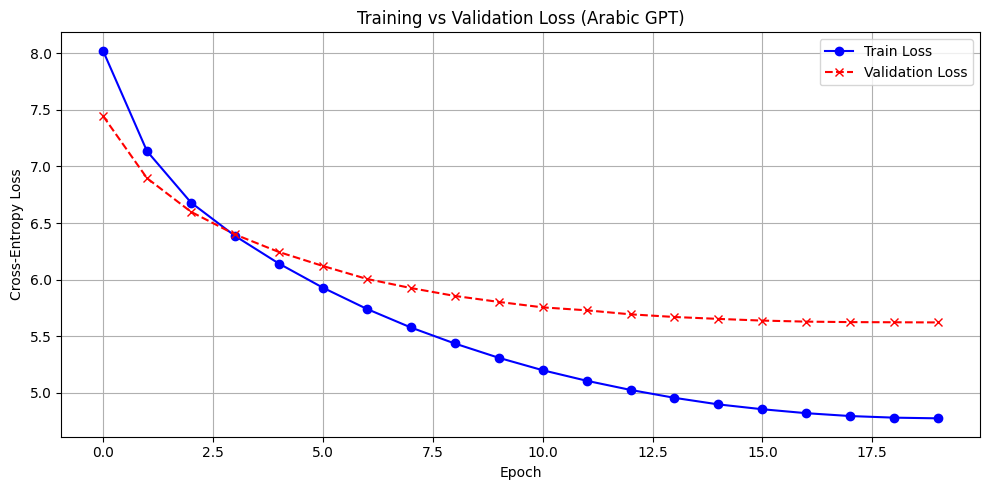


--- Pre-trained Sample ---
قال ابن خلدون، ولا شيء مما يكون من غير مفتحة، ولا يقضى بين يدي الله
وكال ابن الجوزي، وقدمناه، ولا تتخذوا على المسلمين، لا ظل إلا ظله، ولا ظل العرش، ولا ظل إلا الله


In [46]:
# ── Cell 5: Pre-training Loop ─────────────────────────────────────────────────
model = ArabicGPT(cfg)
coach = GPTCoach(model, cfg, device)

train_history = []
val_history   = []

print(f'Starting pre-training on {device}...')
for epoch in range(cfg.epochs):
    t_loss = coach.train_epoch(train_loader)
    v_loss = coach.validate(val_loader)
    train_history.append(t_loss)
    val_history.append(v_loss)
    print(f'Epoch {epoch+1:>2}/{cfg.epochs} | Train: {t_loss:.4f} | Val: {v_loss:.4f}')

# Loss curves
plt.figure(figsize=(10, 5))
plt.plot(train_history, label='Train Loss',      color='blue', marker='o')
plt.plot(val_history,   label='Validation Loss', color='red',  linestyle='--', marker='x')
plt.title('Training vs Validation Loss (Arabic GPT)')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print('\n--- Pre-trained Sample ---')
print(coach.generate('قال ابن خلدون', tokens_to_add=50, temp=0.7))

In [47]:
# ── Cell 6: Save & Load ───────────────────────────────────────────────────────
MODEL_PATH = 'arabic_gpt.pth'   # single consistent name used for both save and load

# Save
torch.save(model.state_dict(), MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')

# ── Optional: save to Google Drive ───────────────────────────────────────────
#from google.colab import drive
#drive.mount('/content/drive')
#drive_path = '/content/drive/MyDrive/arabic_gpt.pth'
#torch.save(model.state_dict(), drive_path)
#print(f'Also saved to Google Drive: {drive_path}')

Model saved to arabic_gpt.pth


In [48]:
# ── Cell 7: Load Pre-trained Model ────────────────────────────────────────────
MODEL_PATH = 'arabic_gpt.pth'

loaded_model = ArabicGPT(cfg).to(device)
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
loaded_model.eval()

loaded_coach = GPTCoach(loaded_model, cfg, device)
print('Model loaded and ready.')

ArabicGPT initialized — 21.16M parameters
Model loaded and ready.


In [49]:
# ── Cell 8: Fine-tuning Data (Aya Instruction Dataset) ───────────────────────
from datasets import load_dataset

dataset = load_dataset('2A2I/Arabic_Aya', 'CohereForAI-aya_collection-aya_dataset', split='train')
df_aya  = dataset.to_pandas()

def format_aya(row):
    """Format each row as an instruction-following example."""
    return f"### السؤال: {row['inputs']}\n### الإجابة: {row['targets']} {tokenizer.eos_token}"

df_aya['text'] = df_aya.apply(format_aya, axis=1)

with open('aya_finetune.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(df_aya['text'].tolist()[:10000]))

print(f'Saved {min(len(df_aya), 10000)} rows to aya_finetune.txt')

# ── Aya Dataset class ─────────────────────────────────────────────────────────
class AyaDataset(Dataset):
    """Tokenizes all examples up-front (fast at epoch time, uses more RAM)."""
    def __init__(self, texts, tokenizer, max_length):
        self.encodings = tokenizer(
            texts.tolist()[:10000],
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        ids = self.encodings['input_ids'][idx]
        return ids, ids   # input == target for causal LM

aya_ds     = AyaDataset(df_aya['text'], tokenizer, cfg.context_length)
aya_loader = DataLoader(aya_ds, batch_size=cfg.batch_size, shuffle=True)
print(f'Aya loader ready — {len(aya_loader)} batches')

Saved 10000 rows to aya_finetune.txt
Aya loader ready — 625 batches


In [50]:
# ── Cell 9: Fine-tuning Loop ──────────────────────────────────────────────────
FINETUNE_EPOCHS = 2   # start with 1; increase if loss is still high
FINETUNE_LR     = 5e-5

ft_optimizer = torch.optim.AdamW(loaded_coach.model.parameters(), lr=FINETUNE_LR)
loaded_coach.model.train()

for epoch in range(FINETUNE_EPOCHS):
    for batch_idx, (inputs, targets) in enumerate(aya_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        ft_optimizer.zero_grad()
        logits = loaded_coach.model(inputs)
        loss   = F.cross_entropy(logits.view(-1, cfg.vocab_size), targets.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(loaded_coach.model.parameters(), 1.0)
        ft_optimizer.step()
        if batch_idx % 10 == 0:
            print(f'Epoch {epoch+1} | Batch {batch_idx:>4} | Loss: {loss.item():.4f}')

# Save the fine-tuned weights
torch.save(loaded_coach.model.state_dict(), 'arabic_gpt_finetuned.pth')
print('Fine-tuned model saved to arabic_gpt_finetuned.pth')

Epoch 1 | Batch    0 | Loss: 14.4134
Epoch 1 | Batch   10 | Loss: 9.4775
Epoch 1 | Batch   20 | Loss: 8.2174
Epoch 1 | Batch   30 | Loss: 7.4247
Epoch 1 | Batch   40 | Loss: 6.4834
Epoch 1 | Batch   50 | Loss: 5.1932
Epoch 1 | Batch   60 | Loss: 4.1513
Epoch 1 | Batch   70 | Loss: 3.5653
Epoch 1 | Batch   80 | Loss: 4.0647
Epoch 1 | Batch   90 | Loss: 3.9064
Epoch 1 | Batch  100 | Loss: 3.0432
Epoch 1 | Batch  110 | Loss: 3.3143
Epoch 1 | Batch  120 | Loss: 2.0899
Epoch 1 | Batch  130 | Loss: 2.8859
Epoch 1 | Batch  140 | Loss: 2.3514
Epoch 1 | Batch  150 | Loss: 2.0074
Epoch 1 | Batch  160 | Loss: 2.0789
Epoch 1 | Batch  170 | Loss: 2.0091
Epoch 1 | Batch  180 | Loss: 1.8596
Epoch 1 | Batch  190 | Loss: 2.6354
Epoch 1 | Batch  200 | Loss: 1.5226
Epoch 1 | Batch  210 | Loss: 1.0274
Epoch 1 | Batch  220 | Loss: 1.6603
Epoch 1 | Batch  230 | Loss: 1.8654
Epoch 1 | Batch  240 | Loss: 1.3017
Epoch 1 | Batch  250 | Loss: 1.5971
Epoch 1 | Batch  260 | Loss: 1.3472
Epoch 1 | Batch  270 | Loss

In [36]:
# ── Cell 10: Gradio Chat Interface ────────────────────────────────────────────
import gradio as gr

def chat_with_sage(message, history, temperature, max_new_tokens):
    """Wrap the user message in the fine-tuning template and generate."""
    user_prompt = (message.get('text', '') if isinstance(message, dict) else str(message)).strip()

    if not user_prompt:
        return 'الرجاء إدخال نص للبدء.'

    # Use the same template the model was fine-tuned on
    formatted_prompt = f'### السؤال: {user_prompt}\n### الإجابة:'

    try:
        full_text = loaded_coach.generate(
            prompt=formatted_prompt,
            tokens_to_add=int(max_new_tokens),
            temp=max(float(temperature), 0.1)  # avoid division by zero
        )
        # Return only the answer part
        if '### الإجابة:' in full_text:
            response = full_text.split('### الإجابة:')[-1].strip()
        else:
            response = full_text
        # Remove any accidentally generated new questions

            response = response.split('###')[0].strip()
        return response or 'لم أستطع إيجاد إجابة دقيقة، حاول صياغة السؤال بشكل آخر.'
    except Exception as e:
        return f'خطأ: {str(e)}'

demo = gr.ChatInterface(
    fn=chat_with_sage,
    type='messages',
    additional_inputs=[
        gr.Slider(0.1, 1.2, value=0.7, label='Temperature (الإبداع)'),
        gr.Slider(10, 300, value=100, step=10, label='Max Tokens (طول النص)'),
    ],
    title='📜 GPT-Arabic Sage | الحكيم العربي',
    description='النموذج مدرب على اتباع التعليمات. اسأله أي شيء بالعربية الفصحى!',
    theme='soft',
    submit_btn='إرسال',
    stop_btn='إيقاف',
)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://09b38f70689792b3be.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://09b38f70689792b3be.gradio.live
